# 🏨 Hotel Booking Demand — Performance Analysis
### Corporate Analyst Portfolio Project
---
**Dataset:** [Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) (Kaggle)
**Tools:** Python · pandas · Matplotlib · SQL (SQLite) · Power BI
**Period:** 2015 – 2017 | 119,208 bookings across City Hotel & Resort Hotel

**Business Questions Answered:**
1. What are the monthly revenue and ADR trends by hotel type?
2. Which market segments carry the highest cancellation risk?
3. Which distribution channels generate the most revenue?
4. How does booking lead time relate to cancellation probability?
5. How accurate is a raw booking count as a revenue forecast?

## 0 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import warnings
warnings.filterwarnings("ignore")

# ── Dark chart theme ──────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3250",
    "axes.labelcolor":  "#c9d1e8",
    "xtick.color":      "#8890b0",
    "ytick.color":      "#8890b0",
    "text.color":       "#c9d1e8",
    "grid.color":       "#2e3250",
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
})
PALETTE = ["#4f8ef7", "#f7904f", "#4fd1a5", "#b04ff7", "#f74f7e"]
print("Setup complete.")

Setup complete.


In [2]:
import os
print("Current directory:", os.getcwd())
print("Files here:", os.listdir("."))

Current directory: /Users/shaonli/Downloads/hotel-booking-analysis/notebooks
Files here: ['hotel_bookings_clean.csv', 'hotel_bookings.csv', 'hotel_booking_analysis.ipynb']


## 1 · Data Loading & Cleaning

Raw data has nulls in `children`, `country`, `agent`, and `company`.
We also remove physically impossible records (negative ADR, zero guests)
and engineer hospitality-specific features.

In [3]:
import os
from pathlib import Path

REPO_ROOT = Path(os.getcwd())
while not (REPO_ROOT / "data").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

MONTH_ORDER = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

df = pd.read_csv("data/hotel_bookings.csv")
print(f"Raw shape: {df.shape}")
print(f"Nulls before cleaning:\n{df.isnull().sum()[df.isnull().sum()>0]}\n")

# Fix nulls
df["children"] = df["children"].fillna(0).astype(int)
df["country"]  = df["country"].fillna("Unknown")
df["agent"]    = df["agent"].fillna(0).astype(int)
df["company"]  = df["company"].fillna(0).astype(int)

# Remove invalid records
df = df[(df["adr"] >= 0) & (df["adr"] <= 1000)]
df = df[(df["adults"] + df["children"] + df["babies"]) > 0]

# Feature engineering
df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"], categories=MONTH_ORDER, ordered=True
)
df["total_nights"]  = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_revenue"] = df["adr"] * df["total_nights"]
df["total_guests"]  = df["adults"] + df["children"] + df["babies"]
df["room_match"]    = (df["reserved_room_type"] == df["assigned_room_type"]).astype(int)
df["arrival_date"]  = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"].astype(str) + "-" +
    df["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d", errors="coerce"
)
df["arrival_yearmon"] = df["arrival_date"].dt.to_period("M")

confirmed = df[df["is_canceled"] == 0]
print(f"Clean shape: {df.shape}")
print(f"\n── Key Metrics ─────────────────────────────────")
print(f"  Total bookings     : {len(df):,}")
print(f"  Cancellation rate  : {df['is_canceled'].mean()*100:.1f}%")
print(f"  Avg ADR            : ${confirmed['adr'].mean():.2f}")
print(f"  Avg stay length    : {confirmed['total_nights'].mean():.1f} nights")
print(f"  Avg lead time      : {df['lead_time'].mean():.0f} days")
print(f"  Est. total revenue : ${confirmed['total_revenue'].sum()/1e6:.1f}M")

Raw shape: (119390, 32)
Nulls before cleaning:
children         4
country        488
agent        16340
company     112593
dtype: int64

Clean shape: (119208, 38)

── Key Metrics ─────────────────────────────────
  Total bookings     : 119,208
  Cancellation rate  : 37.1%
  Avg ADR            : $100.17
  Avg stay length    : 3.4 nights
  Avg lead time      : 104 days
  Est. total revenue : $26.0M


## 2 · Exploratory Data Analysis

### 2.1 Monthly Booking Volume

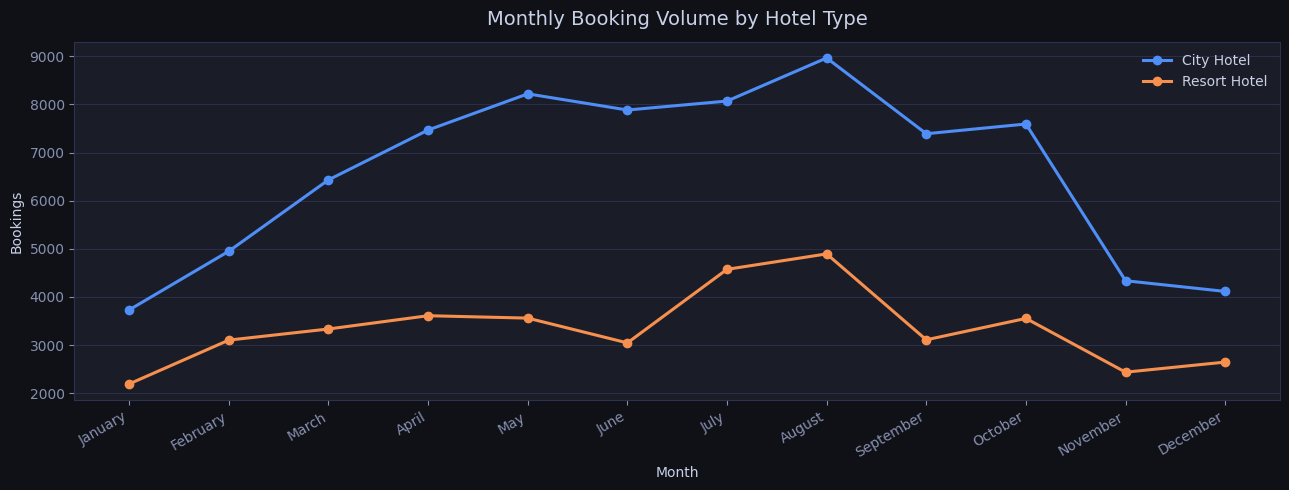

In [4]:
monthly = (df.groupby(["arrival_date_month","hotel"], observed=True)
             .size().reset_index(name="bookings"))

fig, ax = plt.subplots(figsize=(13, 5))
for i, hotel in enumerate(["City Hotel","Resort Hotel"]):
    sub = monthly[monthly["hotel"]==hotel]
    ax.plot(sub["arrival_date_month"].astype(str), sub["bookings"],
            marker="o", lw=2.2, color=PALETTE[i], label=hotel)
ax.set_title("Monthly Booking Volume by Hotel Type", fontsize=14, pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Bookings")
ax.legend(framealpha=0); ax.grid(axis="y")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("outputs/charts/01_monthly_bookings.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

### 2.2 Cancellation Rate by Market Segment

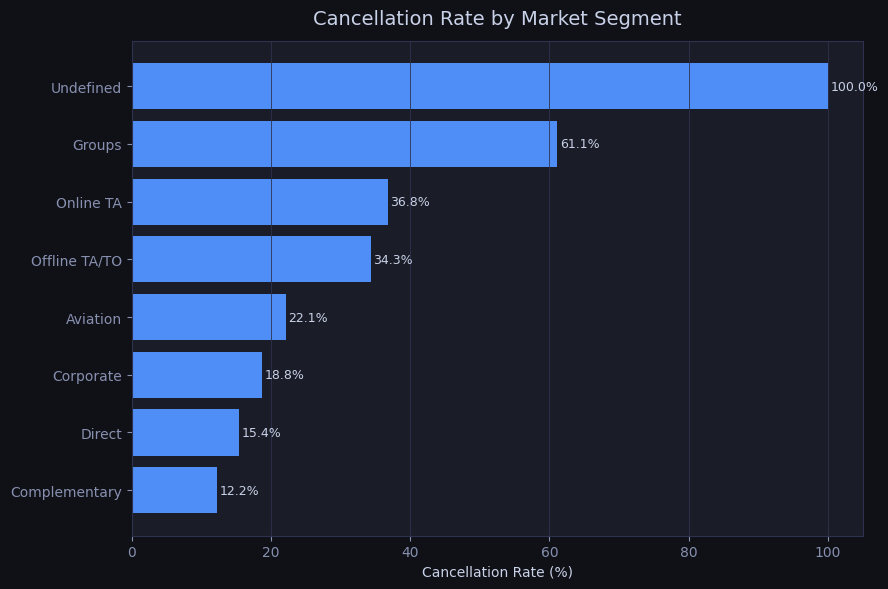

In [5]:
seg = (df.groupby("market_segment")
         .agg(total=("is_canceled","count"), canceled=("is_canceled","sum"))
         .assign(cancel_rate=lambda x: x["canceled"]/x["total"]*100)
         .sort_values("cancel_rate", ascending=True))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(seg.index, seg["cancel_rate"], color=PALETTE[0], edgecolor="none")
for bar, val in zip(bars, seg["cancel_rate"]):
    ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_title("Cancellation Rate by Market Segment", fontsize=14, pad=12)
ax.set_xlabel("Cancellation Rate (%)"); ax.grid(axis="x")
plt.tight_layout()
plt.savefig("outputs/charts/02_cancellation_by_segment.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### 2.3 Average Daily Rate Trend

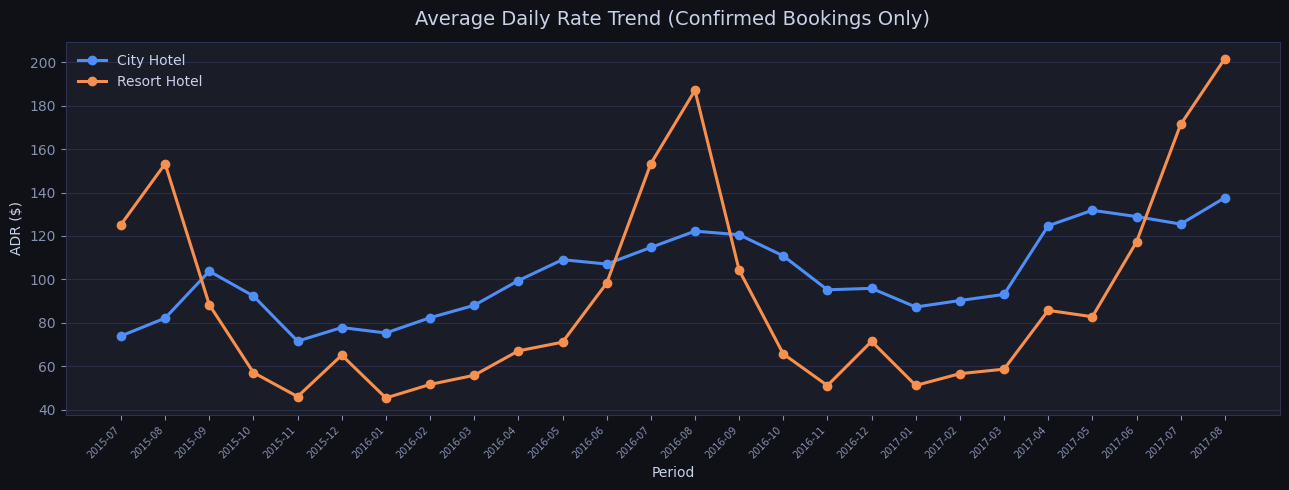

In [6]:
adr_trend = (confirmed.groupby(["arrival_yearmon","hotel"])["adr"]
               .mean().reset_index())
adr_trend["period_str"] = adr_trend["arrival_yearmon"].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
for i, hotel in enumerate(["City Hotel","Resort Hotel"]):
    sub = adr_trend[adr_trend["hotel"]==hotel].sort_values("arrival_yearmon")
    ax.plot(sub["period_str"], sub["adr"],
            marker="o", lw=2.2, color=PALETTE[i], label=hotel)
ax.set_title("Average Daily Rate Trend (Confirmed Bookings Only)", fontsize=14, pad=12)
ax.set_xlabel("Period"); ax.set_ylabel("ADR ($)")
ax.legend(framealpha=0); ax.grid(axis="y")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.savefig("outputs/charts/03_adr_trend.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

### 2.4 Lead Time Distribution

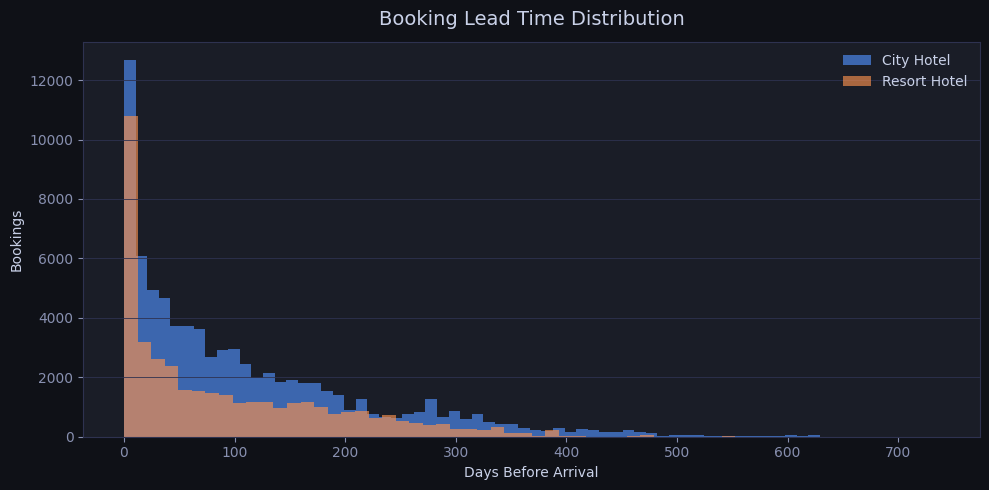

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, hotel in enumerate(["City Hotel","Resort Hotel"]):
    sub = df[df["hotel"]==hotel]["lead_time"]
    ax.hist(sub, bins=60, alpha=0.65, color=PALETTE[i], label=hotel, edgecolor="none")
ax.set_title("Booking Lead Time Distribution", fontsize=14, pad=12)
ax.set_xlabel("Days Before Arrival"); ax.set_ylabel("Bookings")
ax.legend(framealpha=0); ax.grid(axis="y")
plt.tight_layout()
plt.savefig("outputs/charts/04_lead_time_distribution.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### 2.5 Revenue by Distribution Channel

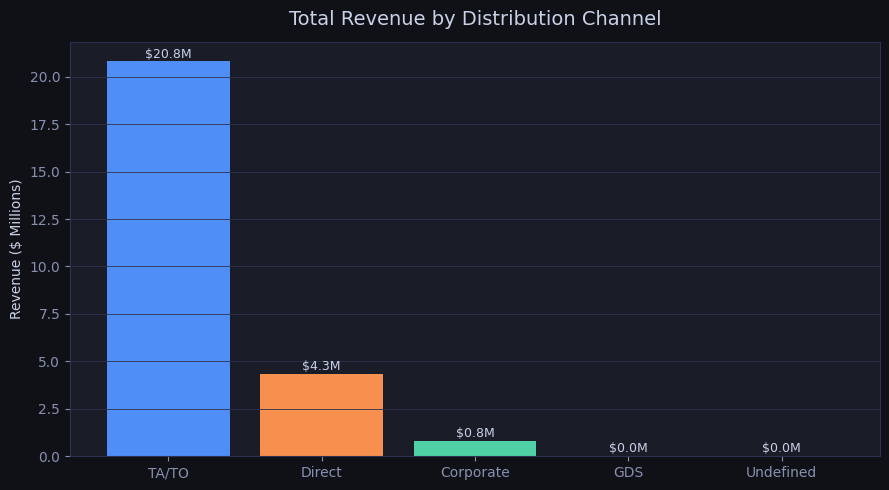

In [8]:
rev_ch = (confirmed.groupby("distribution_channel")["total_revenue"]
            .sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rev_ch.index, rev_ch/1e6, color=PALETTE[:len(rev_ch)], edgecolor="none")
for bar, val in zip(bars, rev_ch/1e6):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.2,
            f"${val:.1f}M", ha="center", fontsize=9)
ax.set_title("Total Revenue by Distribution Channel", fontsize=14, pad=12)
ax.set_ylabel("Revenue ($ Millions)"); ax.grid(axis="y")
plt.tight_layout()
plt.savefig("outputs/charts/05_revenue_by_channel.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

### 2.6 Room Assignment Match Rate

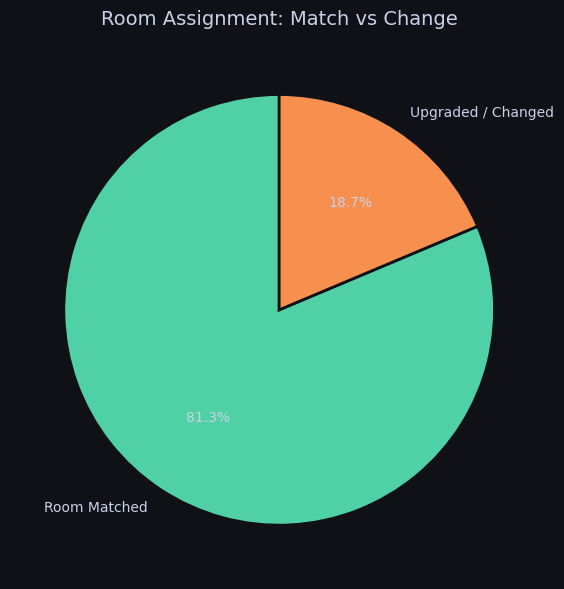

In [9]:
upgrade = confirmed["room_match"].value_counts(normalize=True)*100

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    upgrade.values, labels=["Room Matched","Upgraded / Changed"],
    autopct="%1.1f%%", colors=[PALETTE[2], PALETTE[1]],
    startangle=90, wedgeprops={"edgecolor":"#0f1117","linewidth":2})
for t in texts+autotexts: t.set_color("#c9d1e8")
ax.set_title("Room Assignment: Match vs Change", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("outputs/charts/06_room_assignment.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## 3 · SQL Analysis (SQLite)

The same queries work in SQL Server or PostgreSQL — SQLite is used here
so the notebook runs without any external database setup.

In [11]:
import sqlite3

# Convert Period column to string so SQLite can handle it
df_sql = df.copy()
df_sql["arrival_yearmon"] = df_sql["arrival_yearmon"].astype(str)
df_sql["arrival_date"]    = df_sql["arrival_date"].astype(str)

conn = sqlite3.connect(":memory:")
df_sql.to_sql("hotel_bookings", conn, index=False, if_exists="replace")
print(f"Loaded {len(df_sql):,} rows into SQLite")

Loaded 119,208 rows into SQLite


### 3.1 Cancellation Risk by Segment & Deposit Type

In [12]:
q2 = pd.read_sql("""
SELECT
    market_segment,
    deposit_type,
    COUNT(*)                                        AS total_bookings,
    SUM(is_canceled)                                AS cancellations,
    ROUND(100.0*SUM(is_canceled)/COUNT(*), 1)       AS cancel_rate_pct,
    ROUND(AVG(lead_time), 0)                        AS avg_lead_time_days
FROM hotel_bookings
GROUP BY 1, 2
HAVING total_bookings > 100
ORDER BY cancel_rate_pct DESC
""", conn)
q2

,market_segment,deposit_type,total_bookings,cancellations,cancel_rate_pct,avg_lead_time_days
0,Offline TA/TO,Non Refund,5005,5002,99.9,189.0
1,Groups,Non Refund,9172,9110,99.3,232.0
2,Corporate,Non Refund,334,312,93.4,69.0
3,Online TA,No Deposit,56334,20664,36.7,83.0
4,Groups,No Deposit,10488,2971,28.3,148.0
5,Aviation,No Deposit,235,52,22.1,4.0
6,Offline TA/TO,No Deposit,19172,3297,17.2,121.0
7,Direct,No Deposit,12557,1916,15.3,50.0
8,Corporate,No Deposit,4944,678,13.7,19.0
9,Complementary,No Deposit,728,89,12.2,14.0


### 3.2 Distribution Channel Profitability

In [13]:
q3 = pd.read_sql("""
SELECT
    distribution_channel,
    COUNT(*)                                            AS total_bookings,
    SUM(CASE WHEN is_canceled=0 THEN 1 ELSE 0 END)     AS confirmed,
    ROUND(100.0*SUM(is_canceled)/COUNT(*),1)            AS cancel_rate_pct,
    ROUND(AVG(CASE WHEN is_canceled=0 THEN adr END),2)  AS avg_adr,
    ROUND(SUM(CASE WHEN is_canceled=0
              THEN total_revenue ELSE 0 END),0)         AS total_revenue
FROM hotel_bookings
GROUP BY 1
ORDER BY total_revenue DESC
""", conn)
q3

,distribution_channel,total_bookings,confirmed,cancel_rate_pct,avg_adr,total_revenue
0,TA/TO,97749,57614,41.1,101.78,20802010.0
1,Direct,14610,12055,17.5,106.30,4323529.0
2,Corporate,6651,5184,22.1,67.49,827865.0
3,GDS,193,156,19.2,119.93,33008.0
4,Undefined,5,1,80.0,112.70,564.0


### 3.3 Lead Time Buckets vs Cancellation Rate

In [14]:
q5 = pd.read_sql("""
SELECT
    CASE
        WHEN lead_time=0      THEN '1 Same Day'
        WHEN lead_time<=7     THEN '2 1-7 Days'
        WHEN lead_time<=30    THEN '3 8-30 Days'
        WHEN lead_time<=90    THEN '4 31-90 Days'
        WHEN lead_time<=180   THEN '5 91-180 Days'
        ELSE                       '6 180+ Days'
    END                                                 AS lead_time_bucket,
    COUNT(*)                                            AS bookings,
    ROUND(100.0*SUM(is_canceled)/COUNT(*),1)            AS cancel_rate_pct,
    ROUND(AVG(adr),2)                                   AS avg_adr
FROM hotel_bookings
GROUP BY 1
ORDER BY 1
""", conn)
q5

,lead_time_bucket,bookings,cancel_rate_pct,avg_adr
0,1 Same Day,6264,6.7,84.33
1,2 1-7 Days,13371,11.0,93.34
2,3 8-30 Days,18945,27.9,108.20
3,4 31-90 Days,29528,37.7,106.44
4,5 91-180 Days,26420,44.7,109.19
5,6 180+ Days,24680,57.0,93.04


### 3.4 Monthly Forecast vs Actual Stays

In [15]:
q7 = pd.read_sql("""
SELECT
    arrival_date_year                                   AS year,
    arrival_date_month                                  AS month,
    hotel,
    COUNT(*)                                            AS bookings_made,
    SUM(CASE WHEN is_canceled=0 THEN 1 ELSE 0 END)     AS actual_stays,
    ROUND(100.0*SUM(is_canceled)/COUNT(*),1)            AS cancel_rate_pct
FROM hotel_bookings
GROUP BY 1, 2, 3
ORDER BY 1,
    CASE arrival_date_month
        WHEN 'January' THEN 1 WHEN 'February' THEN 2 WHEN 'March' THEN 3
        WHEN 'April'   THEN 4 WHEN 'May'      THEN 5 WHEN 'June'  THEN 6
        WHEN 'July'    THEN 7 WHEN 'August'   THEN 8 WHEN 'September' THEN 9
        WHEN 'October' THEN 10 WHEN 'November' THEN 11 WHEN 'December' THEN 12
    END, 3
""", conn)
q7.head(24)

,year,month,hotel,bookings_made,actual_stays,cancel_rate_pct
0,2015,July,City Hotel,1396,457,67.3
1,2015,July,Resort Hotel,1378,1058,23.2
2,2015,August,City Hotel,2474,1242,49.8
3,2015,August,Resort Hotel,1409,1043,26.0
4,2015,September,City Hotel,3524,1982,43.8
5,2015,September,Resort Hotel,1585,1034,34.8
6,2015,October,City Hotel,3382,2061,39.1
7,2015,October,Resort Hotel,1569,1158,26.2
8,2015,November,City Hotel,1233,932,24.4
9,2015,November,Resort Hotel,1104,919,16.8


### 3.5 Forecast Accuracy Visualization

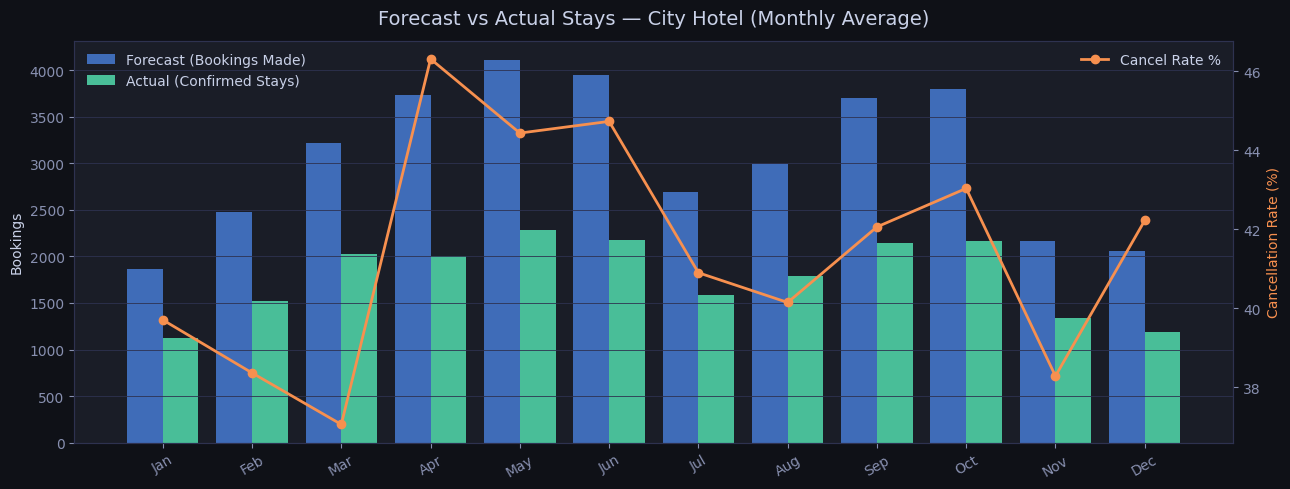

In [16]:
forecast_viz = (q7[q7["hotel"]=="City Hotel"]
                  .groupby("month")[["bookings_made","actual_stays"]]
                  .mean()
                  .reindex(MONTH_ORDER))

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

x = range(len(MONTH_ORDER))
ax1.bar([i-0.2 for i in x], forecast_viz["bookings_made"],
        width=0.4, color=PALETTE[0], alpha=0.7, label="Forecast (Bookings Made)")
ax1.bar([i+0.2 for i in x], forecast_viz["actual_stays"],
        width=0.4, color=PALETTE[2], alpha=0.9, label="Actual (Confirmed Stays)")

cancel_by_month = (df[df["hotel"]=="City Hotel"]
                     .groupby("arrival_date_month", observed=True)["is_canceled"]
                     .mean() * 100)
ax2.plot(x, cancel_by_month.reindex(MONTH_ORDER).values,
         color=PALETTE[1], marker="o", lw=2, label="Cancel Rate %")
ax2.set_ylabel("Cancellation Rate (%)", color=PALETTE[1])

ax1.set_title("Forecast vs Actual Stays — City Hotel (Monthly Average)", fontsize=14, pad=12)
ax1.set_ylabel("Bookings"); ax1.set_xticks(x)
ax1.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=30)
ax1.legend(loc="upper left", framealpha=0)
ax2.legend(loc="upper right", framealpha=0)
ax1.grid(axis="y")
plt.tight_layout()
plt.savefig("outputs/charts/07_forecast_vs_actual.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

conn.close()

## 4 · Key Findings & Business Recommendations

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **37.1% cancellation rate** — nearly double the industry average | Introduce non-refundable deposit tiers with a small discount incentive |
| 2 | **Online TA bookings cancel at 36.7%**, Groups at 28.3% | Apply segment-specific cancellation haircuts to monthly forecasts |
| 3 | **Non-refundable bookings cancel at <1%** | Treat these as near-certain revenue; adjust forecast model accordingly |
| 4 | **Bookings 180+ days out cancel at the highest rate** | Weight long-lead bookings lower in revenue forecasting |
| 5 | **Direct channel has highest ADR ($106) and lowest cancel rate (17.5%)** | Prioritize direct booking investment — better margin and more reliable |
| 6 | **Resort Hotel ADR peaks in July–August ($170–200+)** | Build seasonal ADR targets; flag underperformance early |
| 7 | **City Hotel drives 80%+ of total revenue** | Resource planning and forecasting should center on City Hotel trends |

---
*Analysis based on 119,208 hotel bookings (2015–2017)*
*Source: [Hotel Booking Demand Dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) (Kaggle)*
*Tools: Python · pandas · Matplotlib · SQLite · Power BI*